# Faz 2 — Feature Engineering, Target, Encoding

Faz 1'de kaydedilen `merged_clean.parquet` uzerinden devam ediyoruz.

## 1. Veriyi Yukle ve Sirala

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
FIG_DIR = '../reports/figures'

df = pd.read_parquet('../data/merged_clean.parquet')
df = df.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)
print(df.shape)
df.head()

(456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1436842,1,10,1062,181.39,181.39,0,0,865,Beverages,Italian,590,56,TYPE_B,6.3
1,1205013,2,10,1062,183.36,182.36,0,0,782,Beverages,Italian,590,56,TYPE_B,6.3
2,1447751,3,10,1062,184.36,182.36,0,0,851,Beverages,Italian,590,56,TYPE_B,6.3
3,1014968,4,10,1062,182.36,183.36,0,0,1202,Beverages,Italian,590,56,TYPE_B,6.3
4,1003563,5,10,1062,183.39,181.39,0,0,958,Beverages,Italian,590,56,TYPE_B,6.3


## 2. Feature Engineering

### discount_ratio

In [2]:
df['discount_ratio'] = (df['base_price'] - df['checkout_price']) / df['base_price']
df[['base_price', 'checkout_price', 'discount_ratio']].describe()

,base_price,checkout_price,discount_ratio
count,456548.000000,456548.000000,456548.000000
mean,354.156627,332.238933,0.057195
std,160.715914,152.939723,0.113628
min,55.350000,2.970000,-0.727898
25%,243.500000,228.950000,-0.001454
50%,310.460000,296.820000,0.001412
75%,458.870000,445.230000,0.062421
max,866.270000,866.270000,0.990609


### Lag features — gecen hafta ve 4 hafta oncesi

Lag'lar `(center_id, meal_id)` grubu bazinda, hafta sirasina gore hesaplaniyor. Boylece farkli center/meal kombinasyonlarinin verisi birbirine karismiyor (leakage yok).

In [3]:
grp = df.groupby(['center_id', 'meal_id'])['num_orders']
df['num_orders_lag_1'] = grp.shift(1)
df['num_orders_lag_4'] = grp.shift(4)
df[['center_id', 'meal_id', 'week', 'num_orders', 'num_orders_lag_1', 'num_orders_lag_4']].head(10)

,center_id,meal_id,week,num_orders,num_orders_lag_1,num_orders_lag_4
0,10,1062,1,865,NaN,NaN
1,10,1062,2,782,865.0,NaN
2,10,1062,3,851,782.0,NaN
3,10,1062,4,1202,851.0,NaN
4,10,1062,5,958,1202.0,865.0
5,10,1062,6,1094,958.0,782.0
6,10,1062,7,1513,1094.0,851.0
7,10,1062,8,1149,1513.0,1202.0
8,10,1062,9,1282,1149.0,958.0
9,10,1062,10,1473,1282.0,1094.0


### Rolling mean — 4 haftalik kayan ortalama

Sizinti olmamasi icin once 1 hafta `shift` edilip, sonra son 4 haftanin ortalamasi aliniyor (yani t anindaki satirda t-1..t-4 haftalarinin ortalamasi kullaniliyor).

In [4]:
df['num_orders_roll_mean_4'] = (
    df.groupby(['center_id', 'meal_id'])['num_orders']
      .transform(lambda s: s.shift(1).rolling(4).mean())
)
df[['center_id', 'meal_id', 'week', 'num_orders', 'num_orders_roll_mean_4']].head(10)

,center_id,meal_id,week,num_orders,num_orders_roll_mean_4
0,10,1062,1,865,NaN
1,10,1062,2,782,NaN
2,10,1062,3,851,NaN
3,10,1062,4,1202,NaN
4,10,1062,5,958,925.00
5,10,1062,6,1094,948.25
6,10,1062,7,1513,1026.25
7,10,1062,8,1149,1191.75
8,10,1062,9,1282,1178.50
9,10,1062,10,1473,1259.50


### Hafta numarasindan mevsimsellik

`week` kolonu ardisik (1..145) oldugu icin 52 haftalik donguyle `weekofyear` cikariyoruz ve donguselligi (yil sonu - yil basi yakinligini) modelin yakalayabilmesi icin sin/cos donusumu ekliyoruz.

In [5]:
df['weekofyear'] = ((df['week'] - 1) % 52) + 1
df['week_sin'] = np.sin(2 * np.pi * df['weekofyear'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['weekofyear'] / 52)
df[['week', 'weekofyear', 'week_sin', 'week_cos']].drop_duplicates().head(10)

,week,weekofyear,week_sin,week_cos
0,1,1,0.120537,0.992709
1,2,2,0.239316,0.970942
2,3,3,0.354605,0.935016
3,4,4,0.464723,0.885456
4,5,5,0.568065,0.822984
5,6,6,0.663123,0.748511
6,7,7,0.748511,0.663123
7,8,8,0.822984,0.568065
8,9,9,0.885456,0.464723
9,10,10,0.935016,0.354605


### Lag/rolling sonrasi eksik deger kontrolu

Her `(center_id, meal_id)` grubunun ilk haftalarinda gecmis olmadigi icin NaN olusuyor — bu beklenen bir durum. LightGBM NaN'lari native destekledigi icin doldurmuyoruz, oldugu gibi birakiyoruz.

In [6]:
lag_cols = ['num_orders_lag_1', 'num_orders_lag_4', 'num_orders_roll_mean_4']
print(df[lag_cols].isna().sum())
print('\nToplam satir:', len(df))
print('NaN orani (lag_4): {:.2%}'.format(df['num_orders_lag_4'].isna().mean()))

num_orders_lag_1           3597
num_orders_lag_4          14374
num_orders_roll_mean_4    14374
dtype: int64

Toplam satir: 456548
NaN orani (lag_4): 3.15%


## 3. Target Transformasyonu

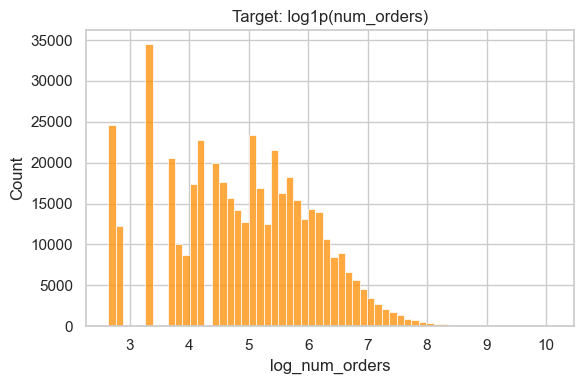

In [7]:
df['log_num_orders'] = np.log1p(df['num_orders'])

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df['log_num_orders'], bins=60, ax=ax, color='darkorange')
ax.set_title('Target: log1p(num_orders)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz2_target_dist.png', dpi=120)
plt.show()

## 4. Kategorik Encoding — Label Encoding

In [8]:
encoders = {}
for col in ['center_type', 'category', 'cuisine']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(col, '->', dict(zip(le.classes_, le.transform(le.classes_))))

with open('../data/label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

center_type -> {'TYPE_A': np.int64(0), 'TYPE_B': np.int64(1), 'TYPE_C': np.int64(2)}
category -> {'Beverages': np.int64(0), 'Biryani': np.int64(1), 'Desert': np.int64(2), 'Extras': np.int64(3), 'Fish': np.int64(4), 'Other Snacks': np.int64(5), 'Pasta': np.int64(6), 'Pizza': np.int64(7), 'Rice Bowl': np.int64(8), 'Salad': np.int64(9), 'Sandwich': np.int64(10), 'Seafood': np.int64(11), 'Soup': np.int64(12), 'Starters': np.int64(13)}


cuisine -> {'Continental': np.int64(0), 'Indian': np.int64(1), 'Italian': np.int64(2), 'Thai': np.int64(3)}


## 5. Yeni Feature'larin Hedefle Iliskisi (saglik kontrolu)

num_orders_roll_mean_4    0.655234
num_orders_lag_1          0.606925
num_orders_lag_4          0.531359
cuisine_enc               0.188148
discount_ratio            0.164188
center_type_enc          -0.062991
category_enc              0.054760
week_cos                  0.023169
week_sin                 -0.006240
Name: log_num_orders, dtype: float64


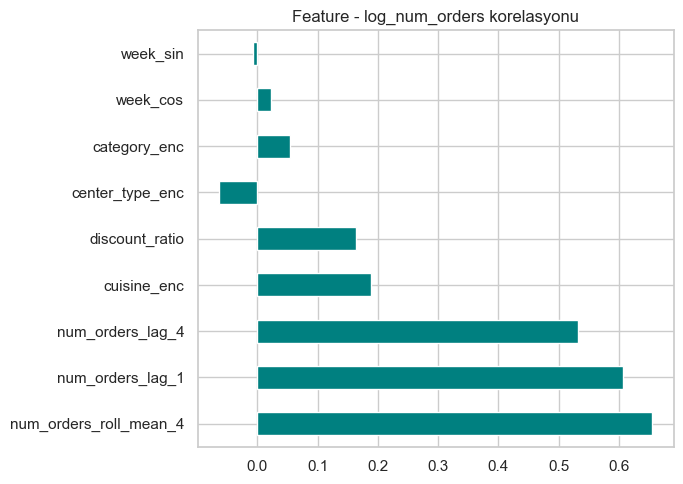

In [9]:
feature_cols = ['discount_ratio', 'num_orders_lag_1', 'num_orders_lag_4',
                'num_orders_roll_mean_4', 'week_sin', 'week_cos',
                'center_type_enc', 'category_enc', 'cuisine_enc']
corr = df[feature_cols + ['log_num_orders']].corr()['log_num_orders'].drop('log_num_orders').sort_values(key=abs, ascending=False)
print(corr)

fig, ax = plt.subplots(figsize=(7, 5))
corr.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Feature - log_num_orders korelasyonu')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz2_feature_correlation.png', dpi=120)
plt.show()

## Ozet

- `discount_ratio`, lag(1,4), 4 haftalik rolling mean ve hafta bazli mevsimsellik (sin/cos) feature'lari eklendi.
- Lag/rolling feature'lar grup (center_id, meal_id) bazinda ve sizinti olmayacak sekilde (shift once, sonra rolling) hesaplandi.
- Hedef `log1p(num_orders)` olarak belirlendi (Faz 1'deki carpiklik analizini dogruluyor).
- `center_type`, `category`, `cuisine` label encoding ile sayisallastirildi, encoder'lar `label_encoders.pkl` olarak saklandi.
- `num_orders_lag_1` ve `num_orders_roll_mean_4` hedefle en yuksek korelasyona sahip -> model icin guclu feature adaylari.

Ozellik muhendisligi tamamlanmis veri seti bir sonraki fazda (`03_modeling.ipynb`) kullanilmak uzere kaydediliyor.

In [10]:
df.to_parquet('../data/features.parquet', index=False)
print('Kaydedildi:', df.shape)
print(df.columns.tolist())

Kaydedildi: (456548, 26)
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'discount_ratio', 'num_orders_lag_1', 'num_orders_lag_4', 'num_orders_roll_mean_4', 'weekofyear', 'week_sin', 'week_cos', 'log_num_orders', 'center_type_enc', 'category_enc', 'cuisine_enc']
